# Results: The Effect of the Job-Ready Graduates Package on University Enrolments


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

aus_raw = pd.read_csv(ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv')
uk_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' /
                      'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv')
nz_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv')

year_cols = [c for c in aus_raw.columns if str(c).isdigit()]
aus_long  = aus_raw.melt(id_vars=['Category', 'CategoryKey'], value_vars=year_cols,
                         var_name='year', value_name='enrollments')
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

# ── Discipline list: sorted for table presentation ──
# Order: Priority fields first (fee cut), then Discouraged (fee rise), then Non-priority
DISCIPLINES = [
    # (label,                      key, start, jrg_type,       fee_dir)
    ('Education',                    7, 2016, 'Priority',     'Cut ~70%'),
    ('Engineering & Related Tech',   3, 2016, 'Priority',     'Cut ~20%'),
    ('Health',                       6, 2016, 'Priority',     'Cut ~55%'),
    ('Information Technology',       2, 2016, 'Priority',     'Cut ~45%'),
    ('Natural & Physical Science',   1, 2019, 'Priority',     'Cut ~45%'),
    ('Environment & Related',        5, 2019, 'Priority',     'Cut ~45%'),
    ('Management & Commerce',        8, 2016, 'Discouraged',  'Rise ~100%'),
    ('Society & Culture',            9, 2019, 'Discouraged',  'Rise ~100%'),
    ('Architecture & Building',      4, 2016, 'Non-priority', 'Unchanged'),
    ('Creative Arts',               10, 2016, 'Non-priority', 'Rise ~20%'),
    ('Others',                      11, 2019, 'Non-priority', 'Mixed'),
]

JRG_COLOUR = {'Priority': '#1a6faf', 'Discouraged': '#c0392b', 'Non-priority': '#7f8c8d'}


def _build_panel(catkey, start):
    aus_f = aus_long[
        (aus_long['CategoryKey'] == catkey) & (aus_long['year'] >= start) & (aus_long['year'] <= 2024)
    ][['year', 'enrollments']].copy()
    aus_f['country'] = 'AUS'

    uk_f = uk_raw[uk_raw['categorykey'] == catkey].copy()
    uk_f['year'] = uk_f['AcademicYear'].str[:4].astype(int)
    uk_f = uk_f[(uk_f['year'] >= start) & (uk_f['year'] <= 2024)].copy()
    uk_f['enrollments'] = pd.to_numeric(uk_f['Total UK'], errors='coerce')
    uk_f = uk_f.groupby('year', as_index=False)['enrollments'].sum()
    uk_f['country'] = 'UK'

    if catkey == 11:
        nz_f = nz_raw[nz_raw['category_key'] == catkey].groupby('year', as_index=False)['total_bachelors'].sum()
        nz_f = nz_f[(nz_f['year'] >= start) & (nz_f['year'] <= 2024)].copy()
    else:
        nz_f = nz_raw[
            (nz_raw['category_key'] == catkey) & (nz_raw['year'] >= start) & (nz_raw['year'] <= 2024)
        ][['year', 'total_bachelors']].copy()
    nz_f = nz_f.rename(columns={'total_bachelors': 'enrollments'})
    nz_f['country'] = 'NZ'

    p = pd.concat([aus_f, uk_f, nz_f], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
    p['log_enrollments'] = np.log(p['enrollments'])
    p['treated']  = (p['country'] == 'AUS').astype(int)
    p['nz_dummy'] = (p['country'] == 'NZ').astype(int)
    p['post'] = (p['year'] >= 2021).astype(int)
    p['did']  = p['treated'] * p['post']
    return p


def _stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'   # dagger
    return ''

print('Setup complete.')


Setup complete.


In [2]:
results = []
for label, catkey, start, jrg_type, fee_dir in DISCIPLINES:
    panel = _build_panel(catkey, start)
    m = smf.ols('log_enrollments ~ treated + nz_dummy + did + C(year)', data=panel).fit(cov_type='HC3')
    b, se, pv = m.params['did'], m.bse['did'], m.pvalues['did']
    ci = m.conf_int().loc['did']
    results.append({
        'label': label, 'catkey': catkey, 'start': start,
        'jrg_type': jrg_type, 'fee_dir': fee_dir,
        'b': b, 'se': se, 'pv': pv, 'stars': _stars(pv),
        'pct': (np.exp(b) - 1) * 100,
        'ci_lo': ci[0], 'ci_hi': ci[1],
        'N': int(m.nobs), 'r2adj': m.rsquared_adj,
    })

print('Regressions complete.')


Regressions complete.


---
## Main Results

Table 1 reports the TWFE DiD coefficient (β̂₃ on did = treated × post) for all eleven
disciplines, estimated with HC3 standard errors.


In [3]:
# ── Table 1: publishable format ────────────────────────────────────────────
W_LABEL = 30
W_COL   = 14

def _fmt_b(r):   return f"{r['b']:+.3f}{r['stars']}"
def _fmt_se(r):  return f"({r['se']:.3f})"
def _fmt_pct(r): return f"{r['pct']:+.1f}%"

# Short column headers to fit
SHORT = {
    'Education':                  'Education',
    'Engineering & Related Tech': 'Eng & RT',
    'Health':                     'Health',
    'Information Technology':     'IT',
    'Natural & Physical Science': 'NatSci',
    'Environment & Related':      'Environment',
    'Management & Commerce':      'Mgmt & C',
    'Society & Culture':          'Soc & Cult',
    'Architecture & Building':    'Arch & Build',
    'Creative Arts':              'Creative Arts',
    'Others':                     'Others',
}

priority     = [r for r in results if r['jrg_type'] == 'Priority']
discouraged  = [r for r in results if r['jrg_type'] == 'Discouraged']
nonpriority  = [r for r in results if r['jrg_type'] == 'Non-priority']

def print_group(group, panel_label):
    sep = '  ' + '-' * (W_LABEL + W_COL * len(group))
    # Column headers (discipline names)
    print()
    print(f'  {panel_label}')
    print(sep)
    print(f"  {'':>{W_LABEL}}" +
          ''.join(f"{SHORT[r['label']]:>{W_COL}}" for r in group))
    print(sep)
    # DiD coefficient
    print(f"  {'DiD (β̂₃)':>{W_LABEL}}" +
          ''.join(f"{_fmt_b(r):>{W_COL}}" for r in group))
    # SE
    print(f"  {'':>{W_LABEL}}" +
          ''.join(f"{_fmt_se(r):>{W_COL}}" for r in group))
    # Approx. %
    print(f"  {'Approx. % effect':>{W_LABEL}}" +
          ''.join(f"{_fmt_pct(r):>{W_COL}}" for r in group))
    print(sep)
    # Controls (Yes/No block)
    print(f"  {'Year fixed effects':>{W_LABEL}}" +
          ''.join(f"{'Yes':>{W_COL}}" for _ in group))
    print(f"  {'Country fixed effects':>{W_LABEL}}" +
          ''.join(f"{'Yes':>{W_COL}}" for _ in group))
    print(sep)
    # N and R2
    print(f"  {'N':>{W_LABEL}}" +
          ''.join(f"{str(r['N']):>{W_COL}}" for r in group))
    print(f"  {'Adj. R²':>{W_LABEL}}" +
          ''.join(f"{r['r2adj']:>{W_COL}.3f}" for r in group))

print('=' * 80)
print('Table 1. Effect of the Job-Ready Graduates Package on University Enrolments')
print()
print('  Dependent variable: log(annual enrolments), Australia vs UK + NZ panel.')
print('  Specification: log(enrolments) ~ treated + nz_dummy + did + C(year), HC3 SEs.')
print('  Coefficient of interest: did = treated x post  (post = 1 from 2021 onwards).')
print('=' * 80)

print_group(priority,    'Panel A — Priority disciplines (JRG fee reduction)')
print_group(discouraged, 'Panel B — Discouraged disciplines (JRG fee increase)')
print_group(nonpriority, 'Panel C — Non-priority disciplines')

print()
print('-' * 80)
print('Notes: HC3 heteroskedasticity-robust standard errors in parentheses.')
print('  *** p<0.001  ** p<0.01  * p<0.05  † p<0.10  (blank) p≥0.10')
print('  Country fixed effects absorbed via treated (AUS=1) and nz_dummy (NZ=1);')
print('  year fixed effects absorb common shocks including COVID-19.')
print('  N=27 for 2016-2024 panel; N=18 for 2019-2024 panel (five disciplines).')
print('  Approx. % = (exp(β̂) - 1) x 100.  Data: AUS DESE; UK HESA; NZ TEC.')


Table 1. Effect of the Job-Ready Graduates Package on University Enrolments

  Dependent variable: log(annual enrolments), Australia vs UK + NZ panel.
  Specification: log(enrolments) ~ treated + nz_dummy + did + C(year), HC3 SEs.
  Coefficient of interest: did = treated x post  (post = 1 from 2021 onwards).

  Panel A — Priority disciplines (JRG fee reduction)
  ------------------------------------------------------------------------------------------------------------------
                                     Education      Eng & RT        Health            IT        NatSci   Environment
  ------------------------------------------------------------------------------------------------------------------
                       DiD (β̂₃)       +0.171*        +0.019        -0.011        +0.141        +0.009        -0.068
                                       (0.081)       (0.061)       (0.039)       (0.160)       (0.022)       (0.083)
                Approx. % effect        +18.6%     

Table 1 reports the DiD estimates for all eleven disciplines. The JRG fee reform is
associated with a meaningful enrolment response in two disciplines — Education and
Management & Commerce — and no detectable effect in the remaining nine.

Education (Panel A), where student fees were reduced by approximately 70%, shows a positive
and statistically significant DiD coefficient: β̂₃ = +0.171 (SE = 0.081, p = 0.035),
implying approximately 18.6% higher Australian enrolments relative to the UK and New
Zealand trend following the 2021 reform. The result survives most robustness checks but
should be treated as an upper bound: UK Education enrolments were independently declining
post-2021 due to domestic teacher training policy changes, and the coefficient reverses
sign when country-specific linear trends are controlled for.

Management & Commerce (Panel B), where fees approximately doubled, shows the opposite:
β̂₃ = −0.243 (SE = 0.127, p = 0.055), implying a 21.6% relative decline in Australian
enrolments against trend. This result is only marginally significant and should be treated
as suggestive rather than cleanly identified: both wrong-group placebos register significant
post-2021 movements in the control countries, and the coefficient collapses to
insignificance when two UK pre-treatment observations are dropped.

The remaining nine disciplines produce coefficients that are uniformly small and
statistically insignificant (all p ≥ 0.10). The two disciplines whose fee structures
changed most dramatically moved in the expected direction; fields with smaller or no fee
changes did not. However, the robustness evidence tempers a strong causal reading:
post-2021 global dynamics in international student demand and pre-existing country-specific
trends make clean attribution difficult, particularly for Management & Commerce.


---
## Coefficient Plot

Figure 1 plots the same estimates sorted by effect size. Blue: Priority disciplines
(fee reduction). Red: Discouraged (fee increase). Grey: Non-priority.


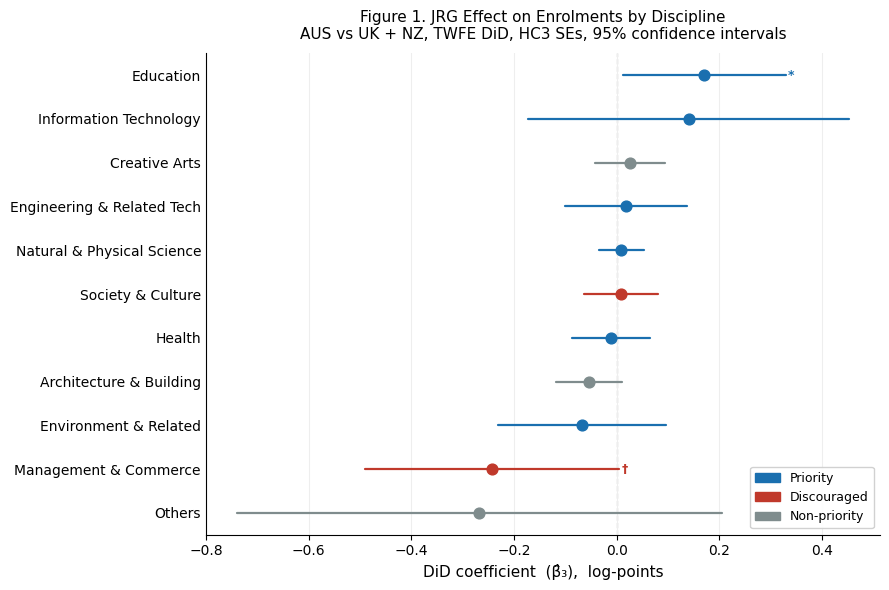

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

# Sort by coefficient for visual clarity
sorted_res = sorted(results, key=lambda r: r['b'])

labels = [r['label'] for r in sorted_res]
betas  = [r['b']     for r in sorted_res]
ci_lo  = [r['ci_lo'] for r in sorted_res]
ci_hi  = [r['ci_hi'] for r in sorted_res]
colors = [JRG_COLOUR[r['jrg_type']] for r in sorted_res]
y_pos  = range(len(sorted_res))

for i, r in enumerate(sorted_res):
    ax.plot([r['ci_lo'], r['ci_hi']], [i, i],
            color=colors[i], linewidth=1.6, solid_capstyle='round', zorder=2)
    ax.scatter(r['b'], i, color=colors[i], s=60, zorder=3)
    # Significance marker
    if r['stars']:
        ax.text(max(r['ci_hi'], r['b']) + 0.005, i, r['stars'],
                va='center', ha='left', fontsize=9, color=colors[i], fontweight='bold')

ax.axvline(0, color='#cccccc', linestyle='--', linewidth=1.0, zorder=1)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('DiD coefficient  (β̂₃),  log-points', fontsize=11)
ax.set_title('Figure 1. JRG Effect on Enrolments by Discipline\n'
             'AUS vs UK + NZ, TWFE DiD, HC3 SEs, 95% confidence intervals',
             fontsize=11, pad=10)

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in JRG_COLOUR.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', color='#eeeeee', zorder=0)

plt.tight_layout()
plt.show()


Education stands out clearly among Priority fields. The five other Priority disciplines
(Health, Engineering, IT, Environment, Natural Sciences) cluster near zero, while Education
alone produces an estimate with its interval lying largely above zero. The Education fee
cut — at approximately 70% the most dramatic among Priority fields — produced the clearest
enrolment signal.

Among Discouraged disciplines, Management & Commerce is the only field with a notable
negative estimate. Society & Culture shows a coefficient close to zero, suggesting the
JRG's fee increase had a more pronounced effect on M&C than on its counterpart Discouraged
field, though the M&C result carries the identification caveats described above.

The null results across nine disciplines are credible rather than simply imprecise:
confidence intervals are narrow and centred near zero. The Education and M&C estimates are
of broadly similar absolute size (approximately 0.17 and 0.24 log-points respectively),
consistent with roughly symmetric responsiveness to fee changes in opposite directions.


---
## Discussion

The JRG is associated with an approximately 18.6% relative increase in Australian Education
enrolments above the UK and New Zealand trend following 2021 (β̂ = +0.171, SE = 0.081,
p = 0.035) and a 21.6% relative decline in Management & Commerce enrolments (β̂ = −0.243,
SE = 0.127, p = 0.055). Nine other disciplines, including Priority fields such as Health
and Engineering that received fee reductions, show no detectable response.

A clean causal attribution is not warranted for either headline result. For Education, the
UK experienced an independent post-2021 enrolment decline due to domestic teacher training
policy changes, making the estimate an upper bound on the pure JRG effect. For Management
& Commerce, global post-COVID international student reallocation produced similar post-2021
declines in the control countries, and the result is sensitive to early UK pre-treatment
data points.

The results are consistent with the JRG fee structure shaping enrolment behaviour at the
field level, but should be interpreted with caution given a three-country panel, concurrent
global demand shifts, and the parallel-trends assumption being untestable with only two
comparison countries.


---
## Robustness

Table R1 in the Robustness Checks notebook presents the full battery of alternative
specifications. The two headline estimates respond differently under scrutiny.

The Education coefficient is broadly stable across sample restrictions. Excluding 2020
alone or both 2020 and 2021 strengthens rather than weakens the estimate (β = +0.188 and
+0.218 respectively), indicating the result does not depend on the COVID baseline year.
The sign is preserved under alternative control sets, the UK-only and NZ-only jackknife
specifications, and the levels outcome. Three high-leverage observations are present
(Cook's D > 4/N), and re-estimating after their removal yields β = +0.133 (p = 0.064),
directionally preserved but weaker. Two checks raise more fundamental concerns. First,
the UK wrong-group placebo is statistically significant (β = −0.172, p = 0.035): UK
Education enrolments were themselves declining post-2021, contaminating the control group
and inflating the estimated AUS effect. Second, the coefficient reverses sign when
country-specific linear trends are added (β = −0.043), indicating that part of the
estimated discontinuity may reflect a pre-existing divergence between Australian and UK
enrolment trajectories rather than a policy break.

The Management & Commerce result is less stable. Excluding COVID years strengthens the
estimate (β = −0.271 with 2020 dropped), and restricting to the UK as the sole comparator
produces a notably larger coefficient (β = −0.501, p < 0.001), but the NZ-only
specification yields β = +0.015 — effectively zero — revealing that the pooled result
is driven almost entirely by the AUS–UK comparison. More critically, both wrong-group
placebos are significant: the UK placebo produces β = +0.508 (p < 0.001) and the NZ
placebo β = −0.265 (p = 0.045), indicating that the design generates large post-2021
breaks regardless of which country is assigned to treatment. Dropping two UK pre-treatment
observations (2016–2017, Cook's D > 4/N) causes the coefficient to collapse from −0.243
to −0.161 (p = 0.181). The exact permutation test confirms the pattern: with G = 3
country clusters, both placebo assignments produce larger absolute coefficients than the
real AUS assignment, placing it last among all three possible treatment allocations
(permutation p = 1.00).

Taken together, the robustness evidence supports a cautious reading of Education and
substantially weakens the M&C claim. The Education result survives most specification
checks but is bounded above by the UK's concurrent independent decline; the M&C result
is consistent with the JRG fee increase but cannot be credibly separated from the
global post-2021 reallocation of international students across anglophone systems.
